# Model Project

Import and set magics:

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# autoreload modules when code is run
%load_ext autoreload
%autoreload 2

# user written modules
from Worker import WorkerClass  # Importing the WorkerClass from Worker module
from Government import GovernmentClass  # Importing the GovernmentClass from Government module

## 1 Labor Supply
### 1.1 Numerical optimizer vs root-finder

ε=1.0
  l* optimizer: 8.2656, c = 4.0328, U = 0.8821, time = 0.000382s
  l* root-finder: 8.2656, c = 4.0328, U = 0.8821, time = 0.000103s

ε=0.75
  l* optimizer: 11.1360, c = 5.4680, U = 1.1170, time = 0.000112s
  l* root-finder: 11.1360, c = 5.4680, U = 1.1170, time = 0.000079s

ε=0.5
  l* optimizer: 16.0000, c = 7.9000, U = 1.4269, time = 0.000246s
  l* root-finder: 0.2000, c = 0.0000, U = -19.1147, time = 0.000024s



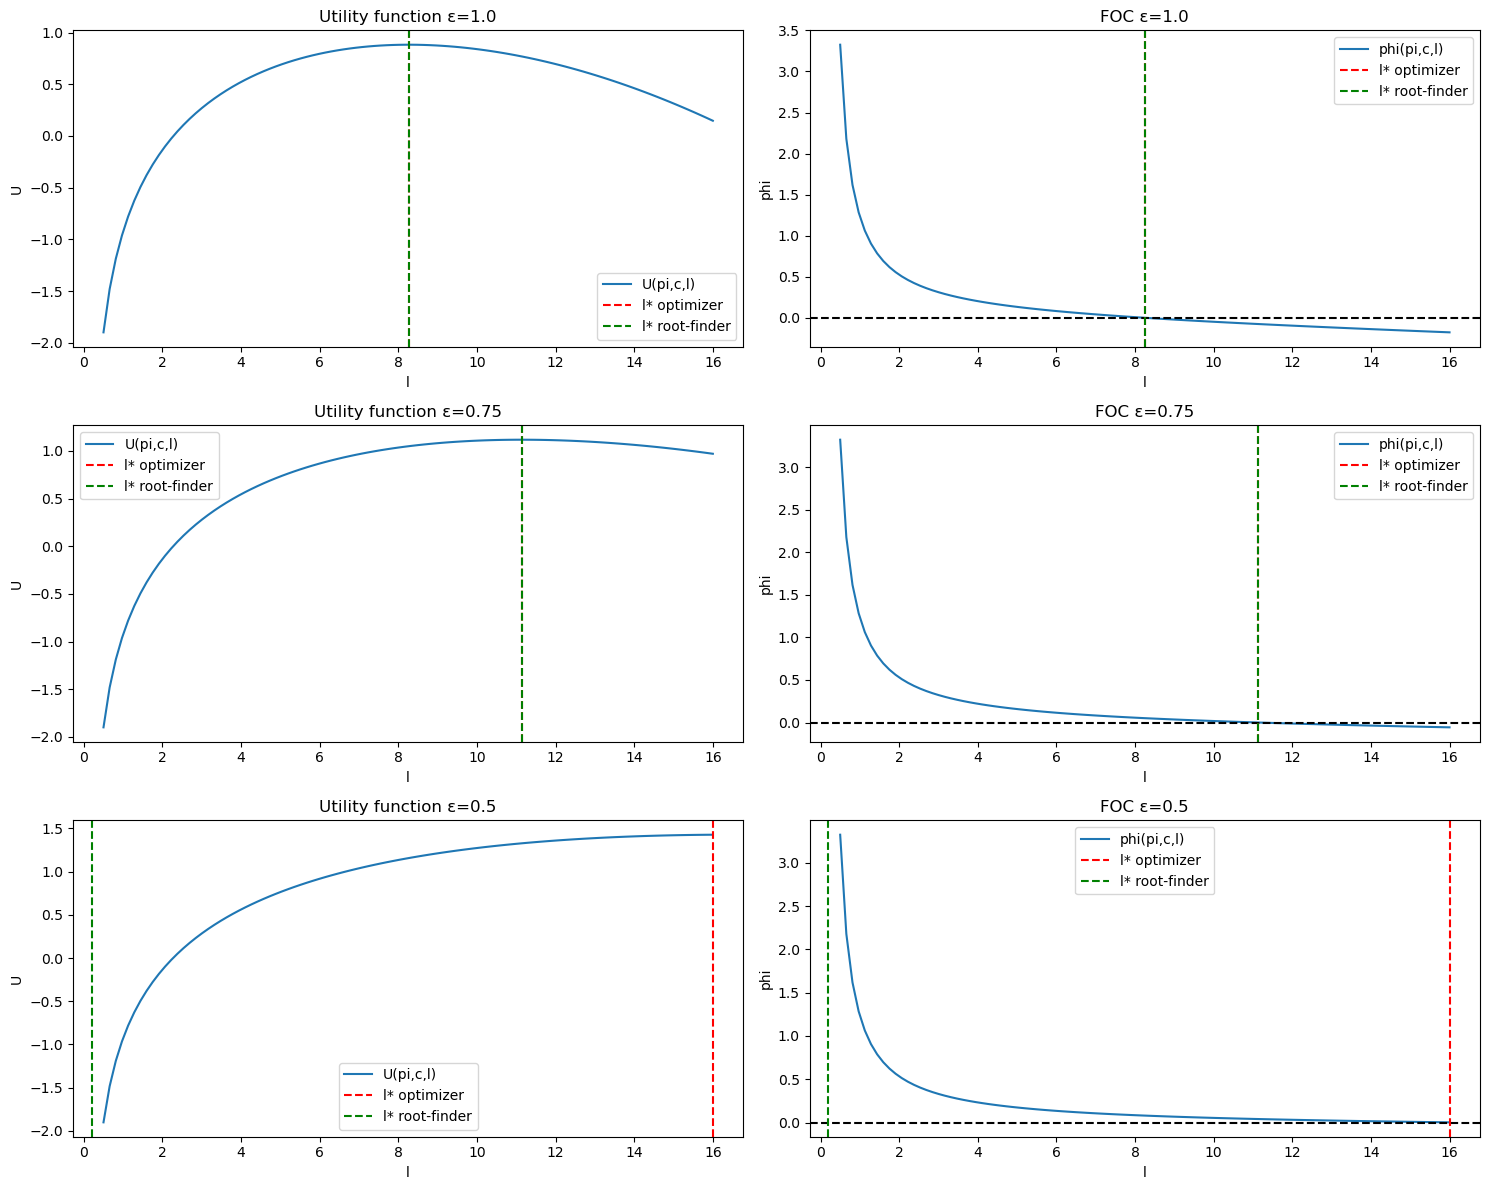

In [ ]:
import time

pi = 1
eps_values = [1.0, 0.75, 0.50]

# Figure setup
plt.figure(figsize=(15, 12))

for i, eps in enumerate(eps_values, 1):
    # 1. Init worker and set epsilon
    worker = WorkerClass()
    worker.par.epsilon = eps
    
    # 2. l-values and calculating u + FOC
    l_vals = np.linspace(0.5, worker.par.ell_max, 100)
    U_vals = [worker.value_of_choice(pi, l) for l in l_vals]
    phi_vals = [worker.FOC(pi, l) for l in l_vals]
    
    # 3. Optimal l* with optimizer
    t0 = time.time()
    opt1 = worker.optimal_choice(pi)
    time_opt = time.time() - t0
    
    # 4. Optimal l* with root-finder
    t0 = time.time()
    opt2 = worker.optimal_choice_FOC(pi)
    time_root = time.time() - t0

    # 5. Printing results
    print(f"ε={eps}")
    print(f"  l* optimizer: {opt1.ell:.4f}, c = {opt1.c:.4f}, U = {opt1.U:.4f}, time = {time_opt:.6f}s")
    print(f"  l* root-finder: {opt2.ell:.4f}, c = {opt2.c:.4f}, U = {opt2.U:.4f}, time = {time_root:.6f}s\n")
    
    # 6. Plots
    plt.subplot(3,2,2*i-1)
    plt.plot(l_vals, U_vals, label='U(pi,c,l)')
    plt.axvline(opt1.ell, color='r', linestyle='--', label='l* optimizer')
    plt.axvline(opt2.ell, color='g', linestyle='--', label='l* root-finder')
    plt.xlabel('l'); plt.ylabel('U')
    plt.title(f'Utility function ε={eps}')
    plt.legend()
    
    plt.subplot(3,2,2*i)
    plt.plot(l_vals, phi_vals, label='phi(pi,c,l)')
    plt.axhline(0, color='k', linestyle='--')
    plt.axvline(opt1.ell, color='r', linestyle='--', label='l* optimizer')
    plt.axvline(opt2.ell, color='g', linestyle='--', label='l* root-finder')
    plt.xlabel('l'); plt.ylabel('phi')
    plt.title(f'FOC ε={eps}')
    plt.legend()

plt.tight_layout()
plt.show()

The optimal labor supply l*, the corresponding consumption c*, and the achieved utility level U are identical across the numerical optimizer and the FOC-based root-finder. This confirms that both methods correctly identify the solution to the worker’s optimization problem.
This isn`t the case for epsilon=0.5, here the FOC fails to find the optimal economic solution.

The root-finder is consistently faster than the numerical optimizer because it solves a one-dimensional equation (the FOC), while the optimizer relies on global maximization of the entire utility function. Therefore, the optimizer requires more function evaluations and convergence steps.

### 1.2 Labor supply function

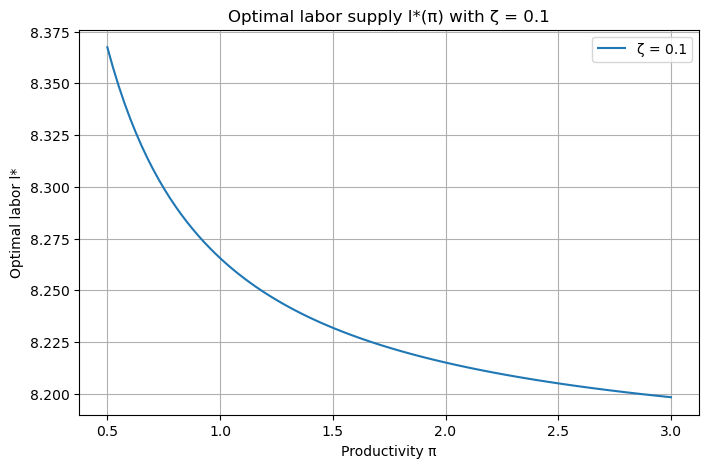

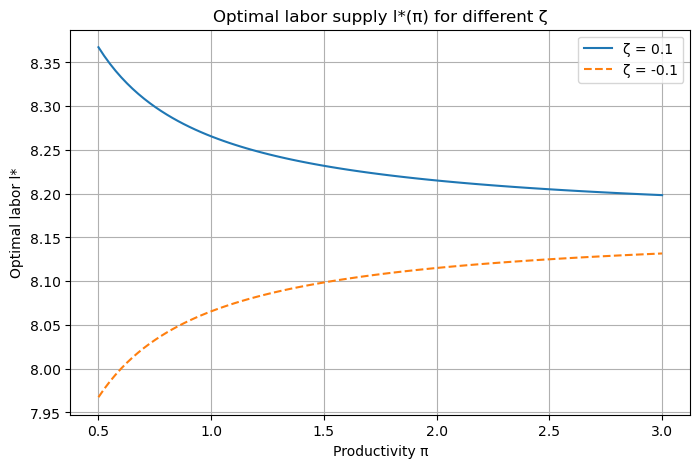

In [ ]:
# Range of productivity
pi_vals = np.linspace(0.5, 3.0, 100)

# Case 1: default zeta 
worker = WorkerClass()  # default ζ = 0.1
l_star_default = []

for pi in pi_vals:
    opt = worker.optimal_choice(pi)   
    l_star_default.append(opt.ell)

# Plotting optimal labor supply
plt.figure(figsize=(8,5))
plt.plot(pi_vals, l_star_default, label='ζ = 0.1')
plt.xlabel('Productivity π')
plt.ylabel('Optimal labor l*')
plt.title('Optimal labor supply l*(π) with ζ = 0.1')
plt.legend()
plt.grid(True)
plt.show()

# Case 2: zeta = -0.1
worker = WorkerClass()
worker.par.zeta = -0.1  # negative lump-sum tax
l_star_negative_zeta = []

for pi in pi_vals:
    opt = worker.optimal_choice(pi)
    l_star_negative_zeta.append(opt.ell)

# Plot comparison
plt.figure(figsize=(8,5))
plt.plot(pi_vals, l_star_default, label='ζ = 0.1')
plt.plot(pi_vals, l_star_negative_zeta, label='ζ = -0.1', linestyle='--')
plt.xlabel('Productivity π')
plt.ylabel('Optimal labor l*')
plt.title('Optimal labor supply l*(π) for different ζ')
plt.legend()
plt.grid(True)
plt.show()

## 2 Public good
### 2.1 Tax revenue and Social Welfare Function

T(0.5, 0.1)   = 417.91177934248674
SWF(0.5, 0.1) = 174.04529658895513


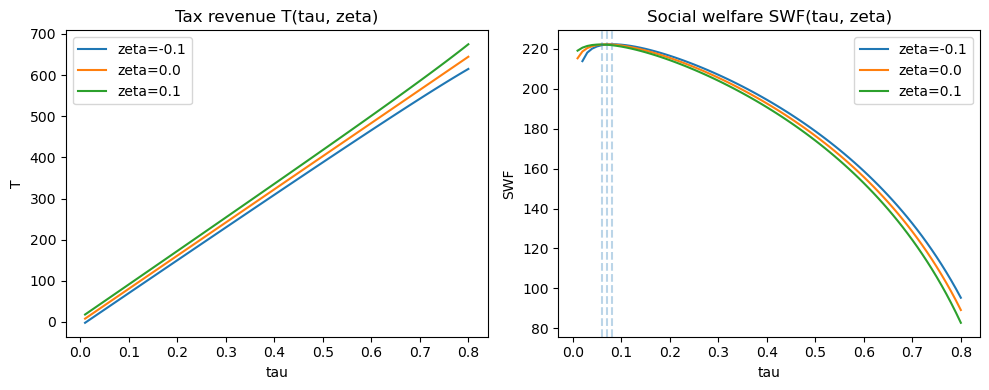

In [ ]:
# Creating government object and drawing productivities once
gov = GovernmentClass()
gov.draw_productivities()

# 1) Computing T and SWF for tau = 0.5 and zeta = 0.1
gov.par.tau, gov.par.zeta = 0.5, 0.1
gov.solve_workers()
print("T(0.5, 0.1)   =", gov.tax_revenue())
print("SWF(0.5, 0.1) =", gov.SWF())

# 2) Plotting T(tau,zeta) and SWF(tau,zeta) for zeta in {-0.1, 0, 0.1}
taus  = np.linspace(0.01, 0.80, 80)
zetas = [-0.1, 0.0, 0.1]

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

for z in zetas:
    gov.par.zeta = z
    T_vals, W_vals = [], []

    for t in taus:
        gov.par.tau = t
        gov.solve_workers()
        T_vals.append(gov.tax_revenue())
        W_vals.append(gov.SWF())

    T_vals = np.array(T_vals)
    W_vals = np.array(W_vals)

    ax[0].plot(taus, T_vals, label=f"zeta={z}")
    ax[1].plot(taus, W_vals, label=f"zeta={z}")

    # 3) Marking the tau that maximizes SWF for this zeta on the grid
    t_star = taus[np.nanargmax(W_vals)]
    ax[1].axvline(t_star, ls="--", alpha=0.3)

ax[0].set_title("Tax revenue T(tau, zeta)")
ax[0].set_xlabel("tau")
ax[0].set_ylabel("T")

ax[1].set_title("Social welfare SWF(tau, zeta)")
ax[1].set_xlabel("tau")
ax[1].set_ylabel("SWF")

for a in ax:
    a.legend()

plt.tight_layout()
plt.show()


For $\tau = 0.5$ and $\zeta = 0.1$ I obtain $T(0.5,0.1) \approx 418$ and $\text{SWF}(0.5,0.1) \approx 174$.
The tax revenue $T(\tau,\zeta)$ increases almost linearly in $\tau$ and shifts up when $\zeta$ is higher.
The social welfare function $\text{SWF}(\tau,\zeta)$ is hump-shaped in $\tau$; it reaches a maximum at an intermediate tax rate (around $\tau \approx 0.08$), and is slightly higher for lower values of $\zeta$.

### 2.2 Optimal tax system

start (0.20, -0.05) -> (0.0821, -0.1000)
start (0.50, 0.10) -> (0.0821, -0.1000)
start (0.70, 0.00) -> (0.0821, -0.1000)

Chosen optimum:
tau*  = 0.08206780481879675
zeta* = -0.1


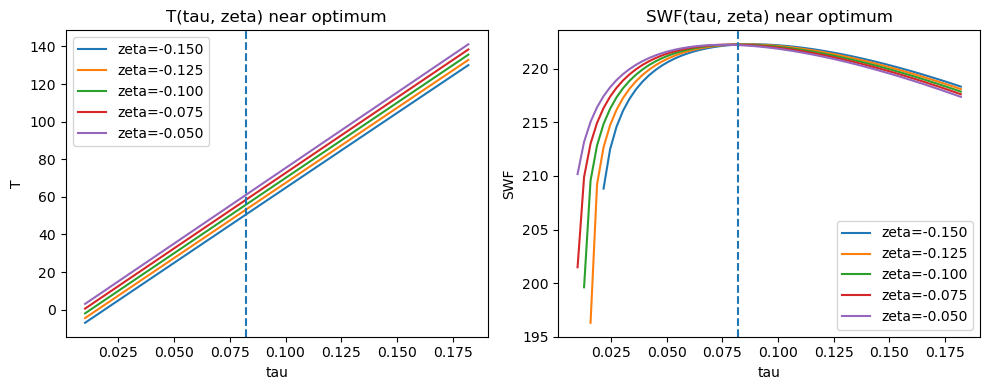

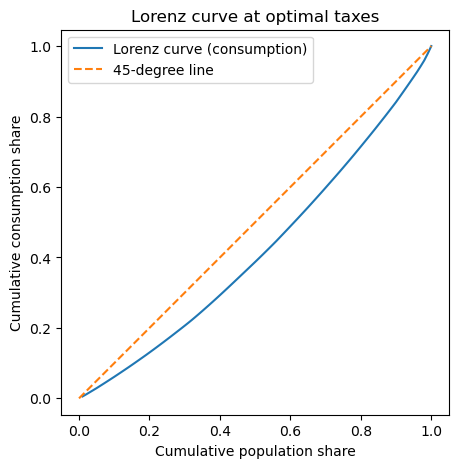

In [ ]:
# 1) Using numerical optimizer to find (tau*, zeta*)
# 2) Checking robustness to different starting values
starts = [(0.2, -0.05), (0.5, 0.1), (0.7, 0.0)]
solutions = []

for t0, z0 in starts:
    res = gov.optimal_taxes(t0, z0)
    tau_star, zeta_star = res.x
    solutions.append((tau_star, zeta_star))
    print(f"start ({t0:.2f}, {z0:.2f}) -> ({tau_star:.4f}, {zeta_star:.4f})")

# Taking the last solution as our reference optimum
tau_star, zeta_star = solutions[-1]
print("\nChosen optimum:")
print("tau*  =", tau_star)
print("zeta* =", zeta_star)

# 3) Plotting T and SWF in a neighborhood of (tau*, zeta*)
taus  = np.linspace(max(0.01, tau_star - 0.1),
                    min(0.80, tau_star + 0.1), 60)
zetas = np.linspace(zeta_star - 0.05, zeta_star + 0.05, 5)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

for z in zetas:
    gov.par.zeta = z
    T_vals, W_vals = [], []

    for t in taus:
        gov.par.tau = t
        gov.solve_workers()
        T_vals.append(gov.tax_revenue())
        W_vals.append(gov.SWF())

    T_vals = np.array(T_vals)
    W_vals = np.array(W_vals)

    ax[0].plot(taus, T_vals, label=f"zeta={z:.3f}")
    ax[1].plot(taus, W_vals, label=f"zeta={z:.3f}")

# Marking tau* in both plots
ax[0].axvline(tau_star, ls="--")
ax[1].axvline(tau_star, ls="--")

ax[0].set_title("T(tau, zeta) near optimum")
ax[0].set_xlabel("tau")
ax[0].set_ylabel("T")

ax[1].set_title("SWF(tau, zeta) near optimum")
ax[1].set_xlabel("tau")
ax[1].set_ylabel("SWF")

for a in ax:
    a.legend()

plt.tight_layout()
plt.show()

# 4) Lorenz curve for consumption at (tau*, zeta*)
gov.par.tau, gov.par.zeta = tau_star, zeta_star
gov.solve_workers()
c = np.sort(np.array(gov.sol.c))
N = len(c)
cum_pop = np.arange(1, N + 1) / N
cum_c = c.cumsum() / c.sum()

plt.figure(figsize=(5, 5))
plt.plot(cum_pop, cum_c, label="Lorenz curve (consumption)")
plt.plot([0, 1], [0, 1], "--", label="45-degree line")
plt.xlabel("Cumulative population share")
plt.ylabel("Cumulative consumption share")
plt.title("Lorenz curve at optimal taxes")
plt.legend()
plt.axis("equal")
plt.show()


Using the `GovernmentClass` and the SWF in (9), we maximize social welfare over $(\tau,\zeta)$ with a numerical optimizer.
Starting from three different initial guesses $(0.20,-0.05)$, $(0.50,0.10)$ and $(0.70,0.00)$, the algorithm always converges to the same solution $(\tau^*,\zeta^*) \approx (0.082,-0.10)$. This shows that the optimum is robust to the choice of starting values.

Plots of $T(\tau,\zeta)$ and $\text{SWF}(\tau,\zeta)$ in a neighborhood around $(\tau^*,\zeta^*)$ confirm the numerical result. Tax revenue is approximately linear in $\tau$, while the social welfare function is concave in $\tau$ with a clear maximum close to $\tau^*$ for all nearby values of $\zeta$. A low proportional tax rate combined with a (negative) lump-sum tax, i.e. a transfer, maximizes social welfare in this calibration.

Finally, the Lorenz curve of consumption at $(\tau^*,\zeta^*)$ lies below the 45-degree line, indicating an unequal but not extremely skewed consumption distribution. With a proportional tax and equal transfers, high-productivity workers finance part of the consumption of low-productivity workers, so the tax system redistributes resources and makes consumption more equal than market income.

## 3 Top tax
### 3.1 Labor supply

In [ ]:
from scipy import optimize

# initializing model
gov = GovernmentClass()
par = gov.par

# storing tau* and zeta* from exercise 2
tau_star  = par.tau      # τ*
zeta_star = par.zeta     # ζ*

# top tax parameters from exercise 3
par.kappa = 9.0          # κ
par.omega = 0.2          # ω

ell_min = 0.5            # lower bound for labor supply
ell_max = par.ell_max    # upper bound (from WorkerClass)

# Defining functions for income, utility, and FOCs

def income_top_tax(pi, ell):
    """
    After-tax income under the top tax:
    y_i = (1 - tau*) w p_i ell - omega * max{w p_i ell - kappa, 0} - zeta*
    """
    labor_income = par.w * pi * ell
    extra_base = np.maximum(labor_income - par.kappa, 0.0)
    y = (1.0 - tau_star) * labor_income - par.omega * extra_base - zeta_star
    return y

def utility(pi, ell):
    """U(p_i, c_i, ell_i) with c_i = y(p_i, ell_i)."""
    c = income_top_tax(pi, ell)
    return gov.utility(c, ell)

def phi_low(ell, pi):
    """
    φ(p_i, c_i, ell_i) = (1 - tau*) w p_i / c_i - nu * ell_i^epsilon
    (used for ell in [0.5, kappa/(w p_i)])
    """
    c = income_top_tax(pi, ell)
    return (1.0 - tau_star) * par.w * pi / c - par.nu * ell**par.epsilon

def phi_high(ell, pi):
    """
    φ̄(p_i, c_i, ell_i) = (1 - tau* - omega) w p_i / c_i - nu * ell_i^epsilon
    (used for ell in [kappa/(w p_i), ell_max])
    """
    c = income_top_tax(pi, ell)
    return (1.0 - tau_star - par.omega) * par.w * pi / c - par.nu * ell**par.epsilon


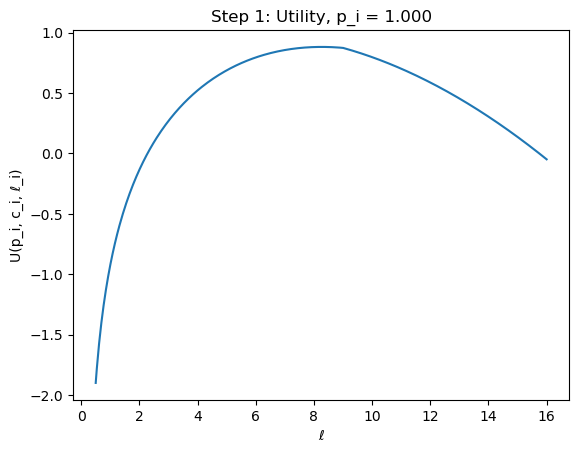

In [ ]:
#3.1.1: plotting U(p_i, c_i, ell_i)

def step1_plot_U(pi):
    ell_grid = np.linspace(ell_min, ell_max, 400)
    U_grid = utility(pi, ell_grid)

    plt.figure()
    plt.plot(ell_grid, U_grid)
    plt.xlabel("ℓ")
    plt.ylabel("U(p_i, c_i, ℓ_i)")
    plt.title(f"Step 1: Utility, p_i = {pi:.3f}")
    plt.show()

# example:
step1_plot_U(1.0)

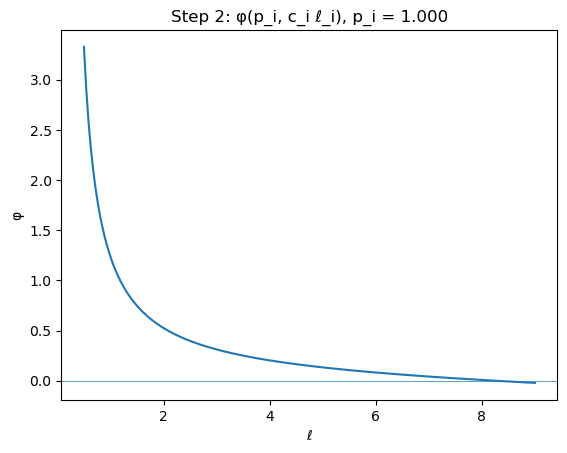

In [8]:
# 3.1.2: plot φ(p_i, c_i ℓ_i) 

def step2_plot_phi(pi):
    ell_k = par.kappa / (par.w * pi)   # kink point
    ell_max_low = min(ell_k, ell_max)

    ell_grid_low = np.linspace(ell_min, ell_max_low, 200)
    phi_grid = phi_low(ell_grid_low, pi)

    plt.figure()
    plt.plot(ell_grid_low, phi_grid)
    plt.axhline(0.0, linewidth=0.5)
    plt.xlabel("ℓ")
    plt.ylabel("φ")
    plt.title(f"Step 2: φ(p_i, c_i ℓ_i), p_i = {pi:.3f}")
    plt.show()

# example:
step2_plot_phi(1.0)


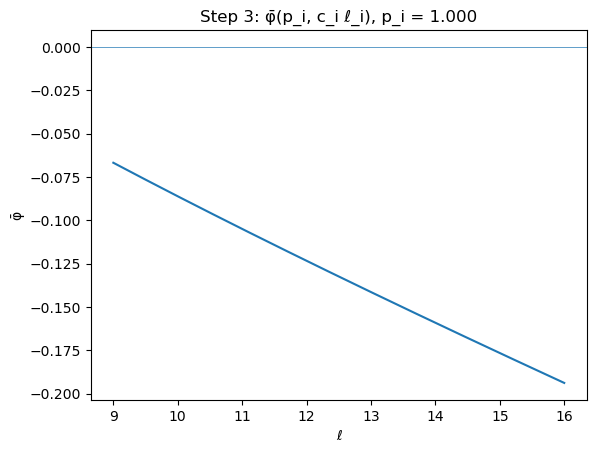

In [9]:
# 3.1.3: plot φ̄(p_i, c_i ℓ_i) 

def step3_plot_phi_bar(pi):
    ell_k = par.kappa / (par.w * pi)
    ell_min_high = max(ell_k, ell_min)

    ell_grid_high = np.linspace(ell_min_high, ell_max, 200)
    phi_bar_grid = phi_high(ell_grid_high, pi)

    plt.figure()
    plt.plot(ell_grid_high, phi_bar_grid)
    plt.axhline(0.0, linewidth=0.5)
    plt.xlabel("ℓ")
    plt.ylabel("φ̄")
    plt.title(f"Step 3: φ̄(p_i, c_i ℓ_i), p_i = {pi:.3f}")
    plt.show()

# example:
step3_plot_phi_bar(1.0)

In [10]:
# 3.1.4: optimal ℓ*(p_i) via numerical optimizer 

def step4_opt_numeric(pi):
    """Maximize U on [ell_min, ell_max] using minimize_scalar."""

    def obj(ell):
        return -float(utility(pi, ell))   # minus because we minimize

    res = optimize.minimize_scalar(
        obj,
        bounds=(ell_min, ell_max),
        method="bounded"
    )
    ell_star_num = res.x
    return ell_star_num

# example:
ell_star_num_1 = step4_opt_numeric(1.0)
print("Step 4, p_i=1.0, ℓ* (numeric) =", ell_star_num_1)

Step 4, p_i=1.0, ℓ* (numeric) = 8.265577471760265


In [ ]:
# 3.1.5: optimal ℓ*(p_i) via 4-step FOC 

def step5_opt_foc(pi):
    """Implement the 4-step FOC procedure from the text."""

    ell_k = par.kappa / (par.w * pi)
    Uminus = -1e10

# We follow the four steps from the task description:
    # Step 1: solve φ = 0 on [ell_min, ell_k]
    ell_b = np.nan
    U_b = Uminus
    if ell_min < ell_k <= ell_max:
        a, b = ell_min, ell_k
        if phi_low(a, pi) * phi_low(b, pi) < 0:
            root = optimize.root_scalar(phi_low, args=(pi,), bracket=[a, b])
            ell_b = root.root
            U_b = float(utility(pi, ell_b))

    # Step 2: kink solution ℓ^k
    ell_k_eff = np.nan
    U_k = Uminus
    if ell_min <= ell_k <= ell_max:
        ell_k_eff = ell_k
        U_k = float(utility(pi, ell_k_eff))

    # Step 3: solve φ̄ = 0 on [ell_k, ell_max]
    ell_a = np.nan
    U_a = Uminus
    if ell_k < ell_max:
        a, b = max(ell_k, ell_min), ell_max
        if phi_high(a, pi) * phi_high(b, pi) < 0:
            root = optimize.root_scalar(phi_high, args=(pi,), bracket=[a, b])
            ell_a = root.root
            U_a = float(utility(pi, ell_a))

    # Step 4: choose the best among ℓ^b, ℓ^k, ℓ^a
    cand_ells = np.array([ell_b, ell_k_eff, ell_a])
    cand_Us   = np.array([U_b,  U_k,      U_a])

    best_index = np.argmax(cand_Us)
    ell_star_foc = cand_ells[best_index]

    return ell_star_foc, cand_ells, cand_Us

# example:
ell_star_foc_1, cand_ells_1, cand_Us_1 = step5_opt_foc(1.0)
print("Step 5, p_i=1.0, ℓ* (FOC) =", ell_star_foc_1)
print("  candidates (ℓ^b, ℓ^k, ℓ^a) =", cand_ells_1)
print("  utilities                 =", cand_Us_1)


Step 5, p_i=1.0, ℓ* (FOC) = 8.265578158750708
  candidates (ℓ^b, ℓ^k, ℓ^a) = [8.26557816 9.                nan]
  utilities                 = [ 8.82059849e-01  8.74104541e-01 -1.00000000e+10]


In [ ]:
# 3.1.6: comparing methods and speed 

def step6_compare(pi):
    t0 = time.perf_counter()
    ell_star_num = step4_opt_numeric(pi)
    t1 = time.perf_counter()

    t2 = time.perf_counter()
    ell_star_foc, cand_ells, cand_Us = step5_opt_foc(pi)
    t3 = time.perf_counter()

    print(f"p_i = {pi:.3f}")
    print(f"  Numerical optimizer : ℓ* = {ell_star_num:.4f}, time = {t1 - t0:.6f} s")
    print(f"  4-step FOC          : ℓ* = {ell_star_foc:.4f}, time = {t3 - t2:.6f} s")
    print("  Candidate ℓ (ℓ^b, ℓ^k, ℓ^a) =", cand_ells)
    print("  Candidate utilities          =", cand_Us)
    print()

# example:
step6_compare(1.0)


p_i = 1.000
  Numerical optimizer : ℓ* = 8.2656, time = 0.000240 s
  4-step FOC          : ℓ* = 8.2656, time = 0.000112 s
  Candidate ℓ (ℓ^b, ℓ^k, ℓ^a) = [8.26557816 9.                nan]
  Candidate utilities          = [ 8.82059849e-01  8.74104541e-01 -1.00000000e+10]



p_i = 1.000
  Numerical optimizer : ℓ* = 8.2656, time = 0.000319 s
  4-step FOC          : ℓ* = 8.2656, time = 0.000136 s
  Candidate ℓ (ℓ^b, ℓ^k, ℓ^a) = [8.26557816 9.                nan]
  Candidate utilities          = [ 8.82059849e-01  8.74104541e-01 -1.00000000e+10]



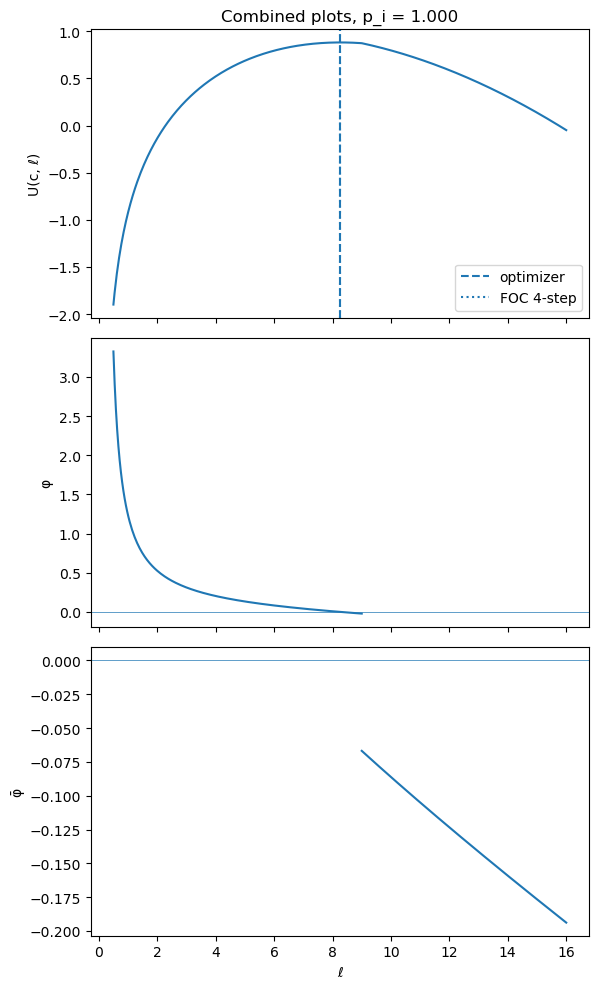

p_i = 1.175
  Numerical optimizer : ℓ* = 7.6596, time = 0.000659 s
  4-step FOC          : ℓ* = 7.6596, time = 0.000071 s
  Candidate ℓ (ℓ^b, ℓ^k, ℓ^a) = [       nan 7.65957447        nan]
  Candidate utilities          = [-1.00000000e+10  1.04158643e+00 -1.00000000e+10]



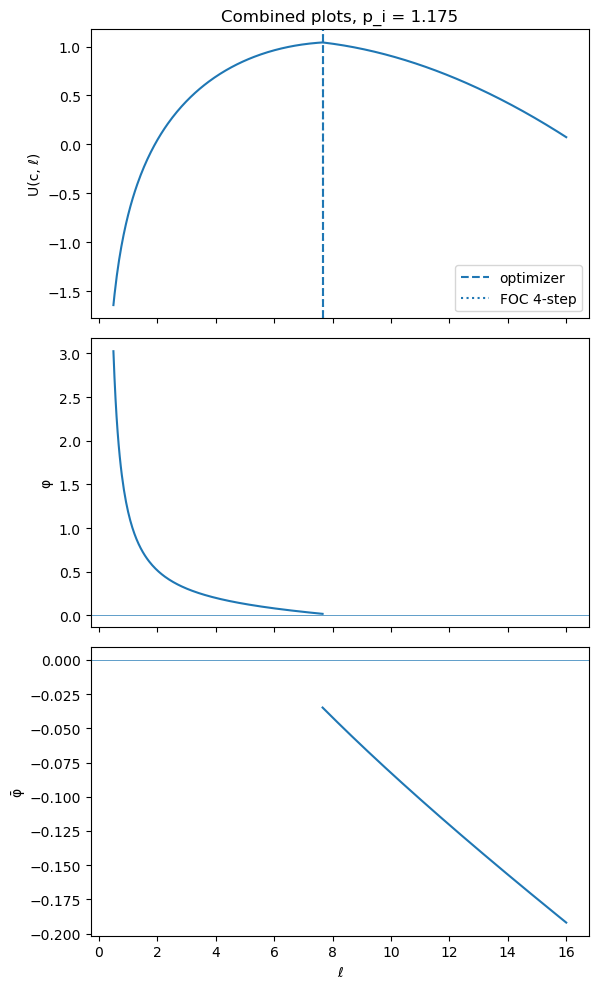

p_i = 1.500
  Numerical optimizer : ℓ* = 6.4917, time = 0.000270 s
  4-step FOC          : ℓ* = 6.4917, time = 0.000097 s
  Candidate ℓ (ℓ^b, ℓ^k, ℓ^a) = [       nan 6.         6.49171777]
  Candidate utilities          = [-1.00000000e+10  1.21160454e+00  1.21460221e+00]



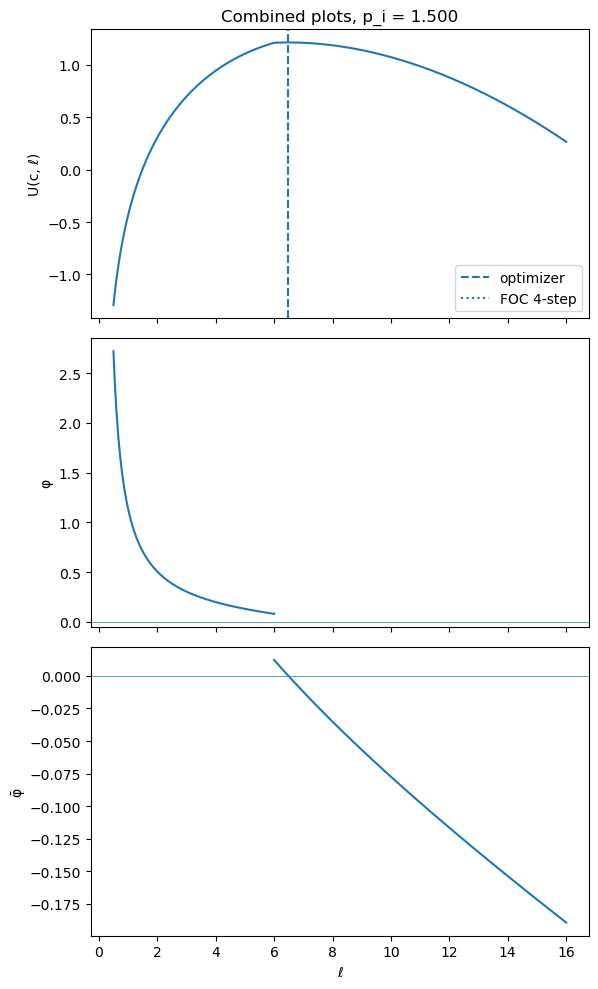

In [13]:
# 3.1.7: combined figure and loop over p_i 

def step7_combined_figure(pi):
    # grids and FOC solution
    ell_grid = np.linspace(ell_min, ell_max, 400)
    U_grid = utility(pi, ell_grid)

    ell_k = par.kappa / (par.w * pi)
    ell_low_max  = min(ell_k, ell_max)
    ell_high_min = max(ell_k, ell_min)

    ell_grid_low  = np.linspace(ell_min,      ell_low_max,  200)
    ell_grid_high = np.linspace(ell_high_min, ell_max,      200)
    phi_low_grid  = phi_low(ell_grid_low,  pi)
    phi_high_grid = phi_high(ell_grid_high, pi)

    ell_star_num = step4_opt_numeric(pi)
    ell_star_foc, _, _ = step5_opt_foc(pi)

    fig, axes = plt.subplots(3, 1, figsize=(6, 10), sharex=True)

    # (1) Utility
    axes[0].plot(ell_grid, U_grid)
    axes[0].axvline(ell_star_num, linestyle="--", label="optimizer")
    axes[0].axvline(ell_star_foc, linestyle=":",  label="FOC 4-step")
    axes[0].set_ylabel("U(c, ℓ)")
    axes[0].set_title(f"Combined plots, p_i = {pi:.3f}")
    axes[0].legend()

    # (2) φ
    axes[1].plot(ell_grid_low, phi_low_grid)
    axes[1].axhline(0.0, linewidth=0.5)
    axes[1].set_ylabel("φ")

    # (3) φ̄
    axes[2].plot(ell_grid_high, phi_high_grid)
    axes[2].axhline(0.0, linewidth=0.5)
    axes[2].set_ylabel("φ̄")
    axes[2].set_xlabel("ℓ")

    plt.tight_layout()
    plt.show()

# Repeating for all three p_i values
for pi in [1.0, 1.175, 1.5]:
    step6_compare(pi)
    step7_combined_figure(pi)


### 3.2 Labor supply funtion

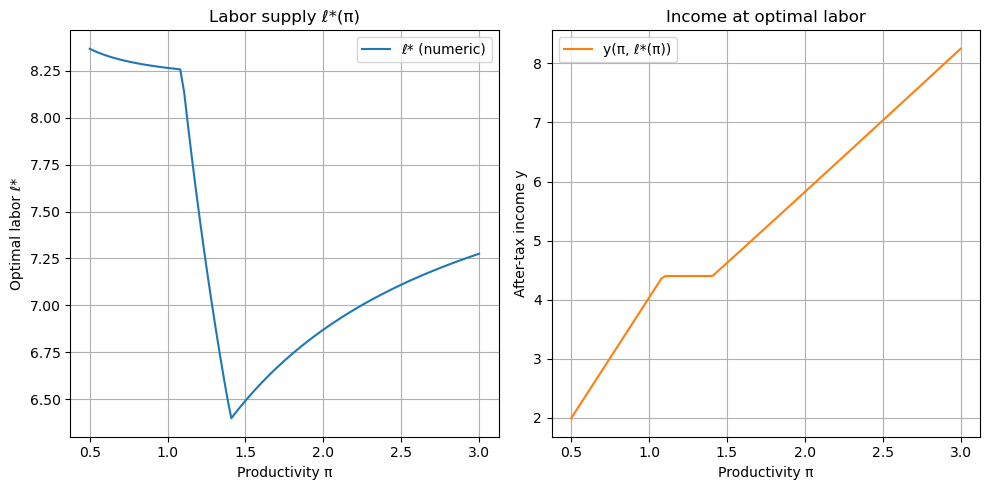

In [14]:
# 3.2.1: Computing and plotting ℓ* (numeric) and income y over pi ∈ [0.5, 3]
pi_vals = np.linspace(0.5, 3.0, 100)

ell_star_num = np.array([step4_opt_numeric(pi) for pi in pi_vals])
y_vals = np.array([income_top_tax(pi, ell) for pi, ell in zip(pi_vals, ell_star_num)])

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.plot(pi_vals, ell_star_num, label='ℓ* (numeric)')
plt.xlabel('Productivity π')
plt.ylabel('Optimal labor ℓ*')
plt.title('Labor supply ℓ*(π)')
plt.grid(True)
plt.legend()

plt.subplot(1,2,2)
plt.plot(pi_vals, y_vals, color='tab:orange', label='y(π, ℓ*(π))')
plt.xlabel('Productivity π')
plt.ylabel('After-tax income y')
plt.title('Income at optimal labor')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()
#

In [15]:
#3.2.2 
# We assume step5_opt_foc(pi) exists and returns:
# ell_star_foc, cand_ells, cand_Us
# where cand_ells = [ell_b, ell_k, ell_a]


# 1) p-grid between 0.5 and 3.0 
p_grid = np.linspace(0.5, 3.0, 100)

def classify_solution_type(pi, atol=1e-6, rtol=1e-6):
    """
    For a given p_i, return which candidate is chosen:
    'b' if ℓ*(p_i) = ℓ_i^b
    'k' if ℓ*(p_i) = ℓ_i^k
    'a' if ℓ*(p_i) = ℓ_i^a
    """
    ell_star, cand_ells, cand_Us = step5_opt_foc(pi)

    labels = ['b', 'k', 'a']
    for idx, lab in enumerate(labels):
        if np.isfinite(cand_ells[idx]) and np.isclose(
            ell_star, cand_ells[idx], atol=atol, rtol=rtol
        ):
            return lab

    # fallback if no match (should not happen)
    return None

# 2) Classifying each p_i on the grid
types = np.array([classify_solution_type(pi) for pi in p_grid])

# 3) Computing proportions
N = len(types)
prop_b = np.mean(types == 'b')
prop_k = np.mean(types == 'k')
prop_a = np.mean(types == 'a')

print(f"Proportion with ℓ*(p_i) = ℓ_i^b: {prop_b:.3f}")
print(f"Proportion with ℓ*(p_i) = ℓ_i^k: {prop_k:.3f}")
print(f"Proportion with ℓ*(p_i) = ℓ_i^a: {prop_a:.3f}")
print(f"Check sum: {prop_b + prop_k + prop_a:.3f}")


Proportion with ℓ*(p_i) = ℓ_i^b: 0.210
Proportion with ℓ*(p_i) = ℓ_i^k: 0.120
Proportion with ℓ*(p_i) = ℓ_i^a: 0.640
Check sum: 0.970


### 3.3 Public good

##### 1. How does the value of the SWF change when introducing the top tax rate? 


In [ ]:
# 1) preparing government and fix the draw so comparisons are on the same population
gov = GovernmentClass()
gov.draw_productivities()         

# storing current tau,zeta so we keep the same baseline fiscal setup
tau_ref = gov.par.tau
zeta_ref = gov.par.zeta

# 2) baseline: no top tax (omega = 0)
gov.par.omega = 0.0              # disables top tax
gov.par.kappa = 1e9
gov.par.tau, gov.par.zeta = tau_ref, zeta_ref
gov.solve_workers()
SWF_baseline = gov.SWF()
c_baseline = np.sort(np.array(gov.sol.c))   # consumption vector for Lorenz

print("Baseline (no top tax):")
print("  tau, zeta:", gov.par.tau, gov.par.zeta)
print("  SWF =", SWF_baseline)

# 3) introducing top tax and recomputing
# choosing candidate top tax parameters (example values)
kappa_new = 9.0   # threshold
omega_new = 0.2   # top marginal tax on income above kappa

# setting them and solving
gov.par.kappa = kappa_new
gov.par.omega = omega_new
gov.par.tau, gov.par.zeta = tau_ref, zeta_ref   # keep baseline tau,zeta
gov.solve_workers()
SWF_top = gov.SWF()
c_top = np.sort(np.array(gov.sol.c))

print("\nWith top tax (kappa={}, omega={}):".format(kappa_new, omega_new))
print("  SWF =", SWF_top)
print("  Absolute change =", SWF_top - SWF_baseline)
print("  Percent change  =", 100.0 * (SWF_top - SWF_baseline) / (abs(SWF_baseline) + 1e-12), "%")

Baseline (no top tax):
  tau, zeta: 0.5 0.1
  SWF = 174.04529658895513

With top tax (kappa=9.0, omega=0.2):
  SWF = 174.04529658895513
  Absolute change = 0.0
  Percent change  = 0.0 %


##### 2. How does the Lorenz-curve for consumption change?

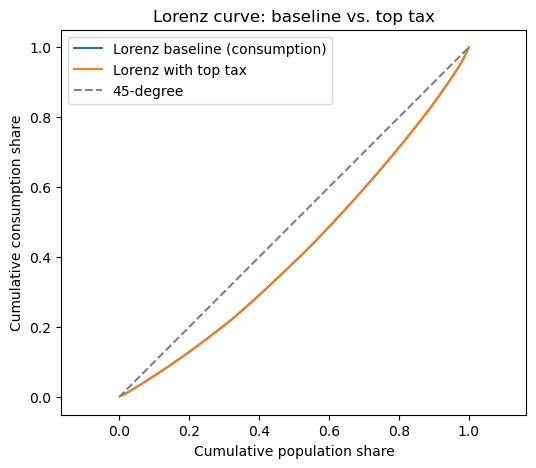

In [ ]:
# 4) plotting Lorenz curves to see distributional effect
import matplotlib.pyplot as plt
N = len(c_baseline)
cum_pop = np.arange(1, N + 1) / N
cum_c_baseline = c_baseline.cumsum() / c_baseline.sum()
cum_c_top      = c_top.cumsum()      / c_top.sum()

plt.figure(figsize=(6,5))
plt.plot(cum_pop, cum_c_baseline, label='Lorenz baseline (consumption)')
plt.plot(cum_pop, cum_c_top, label='Lorenz with top tax')
plt.plot([0,1],[0,1],'--', color='gray', label='45-degree')
plt.xlabel('Cumulative population share')
plt.ylabel('Cumulative consumption share')
plt.title('Lorenz curve: baseline vs. top tax')
plt.legend()
plt.axis('equal')
plt.show()

##### 3. Can you find a ω and κ which implies an improvement in the SWF?


In [30]:
# Optional: coarse grid search for (kappa, omega) that improve SWF
gov.par.omega = 0.0
gov.par.kappa = 1e9
gov.par.tau, gov.par.zeta = tau_ref, zeta_ref
gov.solve_workers()
SWF_baseline = gov.SWF()

kappas = np.linspace(4.0, 12.0, 9)   # example threshold grid
omegas = np.linspace(0.0, 0.4, 9)    # example top rate grid

SWF_grid = np.full((len(kappas), len(omegas)), np.nan)

for i,k in enumerate(kappas):
    for j,o in enumerate(omegas):
        gov.par.kappa = k
        gov.par.omega = o
        gov.par.tau, gov.par.zeta = tau_ref, zeta_ref
        gov.solve_workers()
        SWF_grid[i,j] = gov.SWF()

# show where SWF > baseline
improve = SWF_grid > SWF_baseline
print("Baseline SWF:", SWF_baseline)
print("Number of grid combos that improve SWF:", improve.sum(), "out of", improve.size)



Baseline SWF: 174.04529658895513
Number of grid combos that improve SWF: 0 out of 81


## 4 Extension

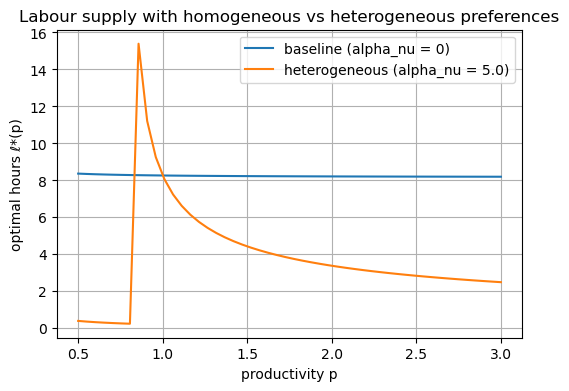

In [ ]:
import Worker_extension as wext

# using WorkerExtension if available, otherwise falling back to baseline worker
WorkerExtension = getattr(wext, "WorkerExtension", WorkerClass)

# baseline model (homogeneous preferences)
worker_base = WorkerClass()

# heterogeneous preferences model
worker_het = WorkerExtension()
worker_het.par.alpha_nu = 5.0   # strength of heterogeneity (can be changed)

# productivity grid
ps = np.linspace(0.5, 3.0, 50)

ells_base = np.empty_like(ps)
ells_het  = np.empty_like(ps)

for i, p in enumerate(ps):
    opt_b = worker_base.optimal_choice_FOC(p)
    opt_h = worker_het.optimal_choice_FOC(p)

    ells_base[i] = opt_b.ell
    ells_het[i]  = opt_h.ell

plt.figure(figsize=(6, 4))
plt.plot(ps, ells_base, label="baseline (alpha_nu = 0)")
plt.plot(ps, ells_het,  label=f"heterogeneous (alpha_nu = {worker_het.par.alpha_nu})")
plt.xlabel("productivity p")
plt.ylabel("optimal hours ℓ*(p)")
plt.title("Labour supply with homogeneous vs heterogeneous preferences")
plt.legend()
plt.grid(True)
plt.show()

We extend the model by allowing the disutility of work to depend on productivity, $v_i(p)=v(1+\alpha_v(p-1))$. With $\alpha_v>0$, high-productivity workers dislike work more. The figure shows that, compared to the baseline with homogeneous preferences, optimal labour supply becomes less steep in productivity: high-productivity workers reduce their hours when their disutility of work is higher, while low-productivity workers are almost unchanged.